In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("mc.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [4]:
#data cleaning + plotly graphs - hw !!
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df = df.drop("CustomerID", axis=1)

In [6]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

In [7]:
print(df.isnull().sum())
print(df.dtypes)

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [8]:
import plotly.express as px
import plotly.graph_objects as go

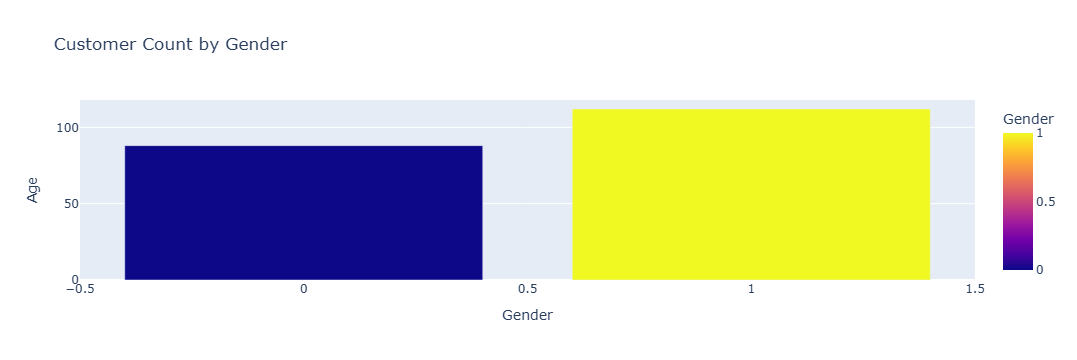

In [9]:
gender_counts = df.groupby('Gender')['Age'].count().reset_index()
fig = px.bar(gender_counts, x='Gender', y='Age', color='Gender', title='Customer Count by Gender')
fig.show()

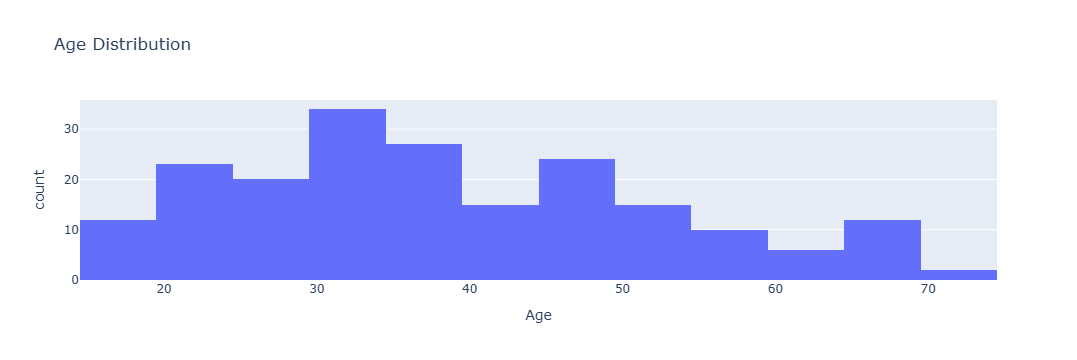

In [10]:
fig = px.histogram(df, x='Age', nbins=20, title='Age Distribution')
fig.show()

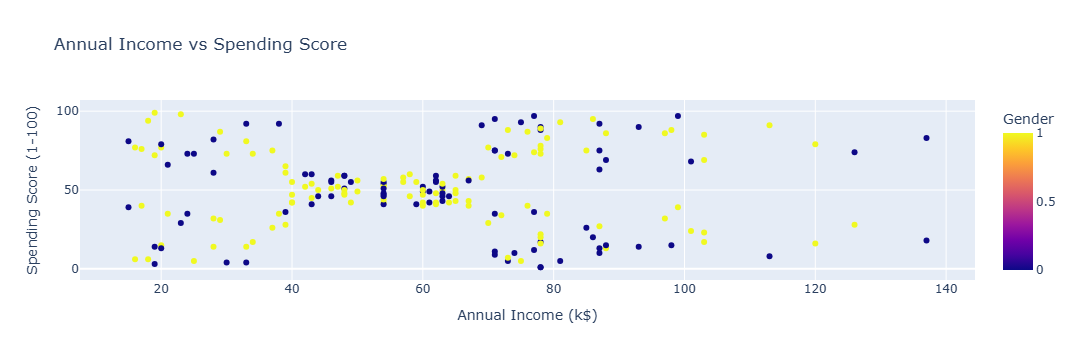

In [11]:
fig = px.scatter(df, x='Annual Income (k$)', y='Spending Score (1-100)', color='Gender', title='Annual Income vs Spending Score')
fig.show()

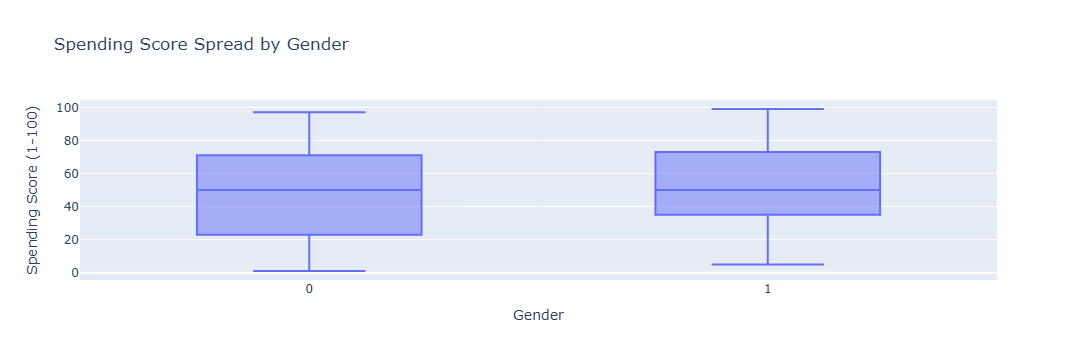

In [12]:
fig = px.box(df, x='Gender', y='Spending Score (1-100)', title='Spending Score Spread by Gender')
fig.show()

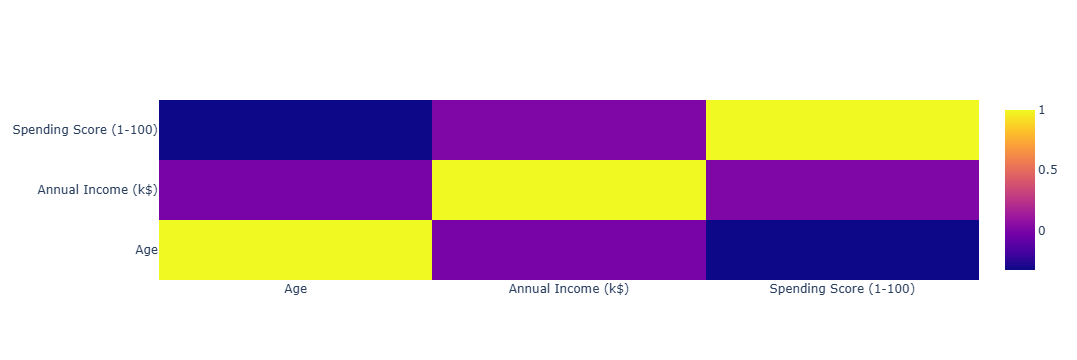

In [13]:
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
fig = go.Figure(data=go.Heatmap(z=corr.values, x=corr.columns, y=corr.columns))
fig.show()